In [ ]:
!pip install -q kaggle
# Upload your kaggle.json file to Colab before running this
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download a subset of the fashion dataset
!kaggle datasets download -d paramaggarwal/fashion-product-images-small
!unzip -q fashion-product-images-small.zip -d dataset

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/paramaggarwal/fashion-product-images-small
License(s): MIT
 96% 542M/565M [00:26<00:00, 24.3MB/s]

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.preprocessing import image
import numpy as np
import os

# Load pretrained ResNet50 without the classification head
base_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')

def extract_features(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    expanded_img = np.expand_dims(img_array, axis=0)
    preprocessed_img = preprocess_input(expanded_img)
    features = base_model.predict(preprocessed_img)
    return features.flatten()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
import random

def generate_triplets(image_paths, labels, num_triplets):
    triplets = []
    # Group images by category using a dictionary map for efficient sampling
    label_to_indices = {label: np.where(labels == label)[0] for label in set(labels)}

    for _ in range(num_triplets):
        # Select random anchor category and anchor/positive images
        anchor_label = random.choice(list(label_to_indices.keys()))

        # Ensure the category has at least 2 items to sample an anchor and a positive
        if len(label_to_indices[anchor_label]) < 2:
            continue

        anchor_idx, positive_idx = random.sample(list(label_to_indices[anchor_label]), 2)

        # Select negative category and negative image
        negative_label = random.choice([l for l in label_to_indices.keys() if l != anchor_label])
        negative_idx = random.choice(list(label_to_indices[negative_label]))

        triplets.append((image_paths[anchor_idx], image_paths[positive_idx], image_paths[negative_idx]))

    return triplets

In [ ]:
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model

def build_siamese_model(base_model):
    # Freeze the base model to act as a feature extractor
    base_model.trainable = False

    anchor_input = Input(shape=(224, 224, 3), name='anchor')
    positive_input = Input(shape=(224, 224, 3), name='positive')
    negative_input = Input(shape=(224, 224, 3), name='negative')

    # Generate embeddings using the shared base model
    emb_a = base_model(anchor_input)
    emb_p = base_model(positive_input)
    emb_n = base_model(negative_input)

    # Output the three embeddings to be evaluated by a triplet loss function
    siamese_net = Model(inputs=[anchor_input, positive_input, negative_input],
                        outputs=[emb_a, emb_p, emb_n])
    return siamese_net

In [ ]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.5/18.5 MB 80.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import os
import glob

# 1. Define the path to your dataset images
# Adjust this path based on where you unzipped the Kaggle dataset
image_folder = "dataset/images"
image_paths = glob.glob(os.path.join(image_folder, "*.jpg"))

# For testing purposes, limit to the first 500 images to save time
image_paths = image_paths[:500]

# 2. Extract features to populate 'all_embeddings'
print("Extracting embeddings for the dataset...")
embeddings_list = []
for path in image_paths:
    features = extract_features(path) # Calls the ResNet50 function from Step 2
    embeddings_list.append(features)

# Convert the list to a 2D NumPy array
all_embeddings = np.array(embeddings_list)
print(f"Shape of all_embeddings: {all_embeddings.shape}")

# 3. Define 'query_embedding' for the search
# Select an image to act as your search query (e.g., the first image in your list)
query_image_path = image_paths[0]
query_embedding = extract_features(query_image_path)
print(f"Shape of query_embedding: {query_embedding.shape}")

Extracting embeddings for the dataset...
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 228ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 429ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 226ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0

In [ ]:
import faiss

# Assuming 'all_embeddings' is a NumPy array of shape (num_images, embedding_dim)
dimension = all_embeddings.shape[1]
# Inner product corresponds to cosine similarity if the vectors are L2 normalized
index = faiss.IndexFlatIP(dimension)
faiss.normalize_L2(all_embeddings)
index.add(all_embeddings)

# Search for top-5 similar images for a given query embedding
k = 5
query = np.expand_dims(query_embedding, axis=0)
faiss.normalize_L2(query)
distances, indices = index.search(query, k)

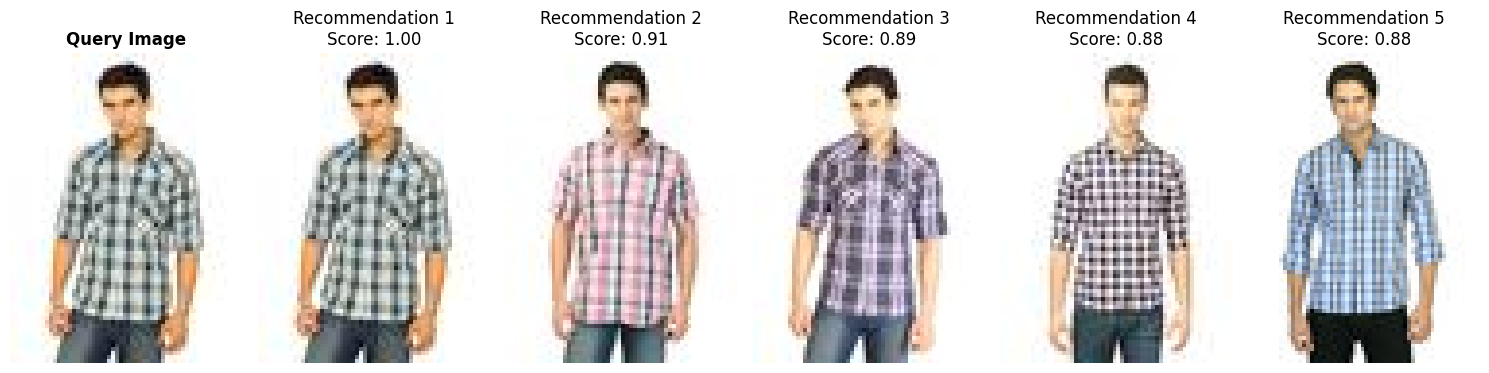

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# The FAISS search returns a 2D array, so we select the first row for our single query
retrieved_indices = indices[0]
retrieved_distances = distances[0]

plt.figure(figsize=(15, 5))

# 1. Plot the original Query Image
plt.subplot(1, k + 1, 1)
query_img = image.load_img(query_image_path)
plt.imshow(query_img)
plt.title("Query Image", fontweight='bold')
plt.axis('off')

# 2. Loop through the indices to plot the recommendations
for i, idx in enumerate(retrieved_indices):
    plt.subplot(1, k + 1, i + 2)

    # Map the FAISS index back to the original image path list
    recommended_img_path = image_paths[idx]
    recommended_img = image.load_img(recommended_img_path)

    plt.imshow(recommended_img)
    # Display the rank and the similarity distance score
    plt.title(f"Recommendation {i+1}\nScore: {retrieved_distances[i]:.2f}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
import json
import pandas as pd

json_path = '/content/fashion-product-images-dataset-metadata.json'

try:
    df = pd.read_json(json_path)
    print("Successfully loaded as DataFrame!")
    display(df.head())
except ValueError:
    with open(json_path, 'r') as file:
        data = json.load(file)
    print("Loaded as a dictionary. Here are the top-level keys:")
    print(data.keys())

Loaded as a dictionary. Here are the top-level keys:
dict_keys(['@context', 'alternateName', 'citeAs', 'conformsTo', 'license', 'distribution', 'recordSet', 'keywords', 'identifier', 'isAccessibleForFree', 'isLiveDataset', 'includedInDataCatalog', 'creator', 'publisher', 'thumbnailUrl', 'dateModified', 'datePublished', '@type', 'name', 'url', 'description'])


In [ ]:
import pandas as pd
import os

csv_path = '/content/dataset/styles.csv'

try:
    styles_df = pd.read_csv(csv_path, on_bad_lines='skip')
    display(styles_df.head())
except FileNotFoundError:
    for root, dirs, files in os.walk('dataset'):
        if 'styles.csv' in files:
            found_path = os.path.join(root, 'styles.csv')
            print(f"File found at: {found_path}")
            styles_df = pd.read_csv(found_path, on_bad_lines='skip')
            display(styles_df.head())
            break

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [ ]:
import os
import numpy as np

# 1. Identify the top 5 most common product categories
top_categories = styles_df['articleType'].value_counts().nlargest(5).index.tolist()
print(f"Selected categories: {top_categories}")

# 2. Filter the DataFrame to only include these selected categories
subset_df = styles_df[styles_df['articleType'].isin(top_categories)]

# 3. Sample exactly 250 items per category to create a balanced subset
balanced_df = subset_df.groupby('articleType').apply(lambda x: x.sample(n=min(len(x), 250))).reset_index(drop=True)

# 4. Map the IDs to their actual image paths and create parallel lists
image_dir = 'dataset/images' # Update this if your images unzipped to a slightly different path
valid_paths = []
valid_labels = []

for index, row in balanced_df.iterrows():
    # Construct the filename using the ID
    img_filename = f"{row['id']}.jpg"
    img_path = os.path.join(image_dir, img_filename)

    # Verify the image file actually exists before adding it to our dataset
    if os.path.exists(img_path):
        valid_paths.append(img_path)
        valid_labels.append(row['articleType'])

# Convert to NumPy arrays for efficient indexing later
filtered_image_paths = np.array(valid_paths)
filtered_labels = np.array(valid_labels)

print(f"Total valid images collected for the subset: {len(filtered_image_paths)}")

Selected categories: ['Tshirts', 'Shirts', 'Casual Shoes', 'Watches', 'Sports Shoes']
Total valid images collected for the subset: 1250


/tmp/ipykernel_759/1594153246.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  balanced_df = subset_df.groupby('articleType').apply(lambda x: x.sample(n=min(len(x), 250))).reset_index(drop=True)


In [ ]:
import random

def create_triplets(image_paths, labels):
    triplets = []

    # Create a dictionary mapping each label to a list of its corresponding image indices
    # This acts as a lookup table for O(1) category access
    label_to_indices = {label: np.where(labels == label)[0] for label in set(labels)}

    # Loop through every single image in our subset to act as an anchor
    for anchor_idx in range(len(image_paths)):
        anchor_label = labels[anchor_idx]

        # 1. Select a Positive image (same category)
        positive_indices = label_to_indices[anchor_label]
        # Filter out the anchor itself so we don't compare an image to itself
        valid_positive_indices = [idx for idx in positive_indices if idx != anchor_idx]
        positive_idx = random.choice(valid_positive_indices)

        # 2. Select a Negative image (different category)
        negative_label = random.choice([label for label in label_to_indices.keys() if label != anchor_label])
        negative_idx = random.choice(label_to_indices[negative_label])

        # Append the actual file paths as a tuple
        triplets.append((image_paths[anchor_idx], image_paths[positive_idx], image_paths[negative_idx]))

    return triplets

# Generate the triplets using our filtered dataset arrays
triplet_paths = create_triplets(filtered_image_paths, filtered_labels)
print(f"Successfully generated {len(triplet_paths)} image triplets.")

# Let's peek at the first triplet to verify
print("\nSample Triplet (Anchor, Positive, Negative):")
for path in triplet_paths[0]:
    print(path)

Successfully generated 1250 image triplets.

Sample Triplet (Anchor, Positive, Negative):
dataset/images/39253.jpg
dataset/images/4282.jpg
dataset/images/1587.jpg


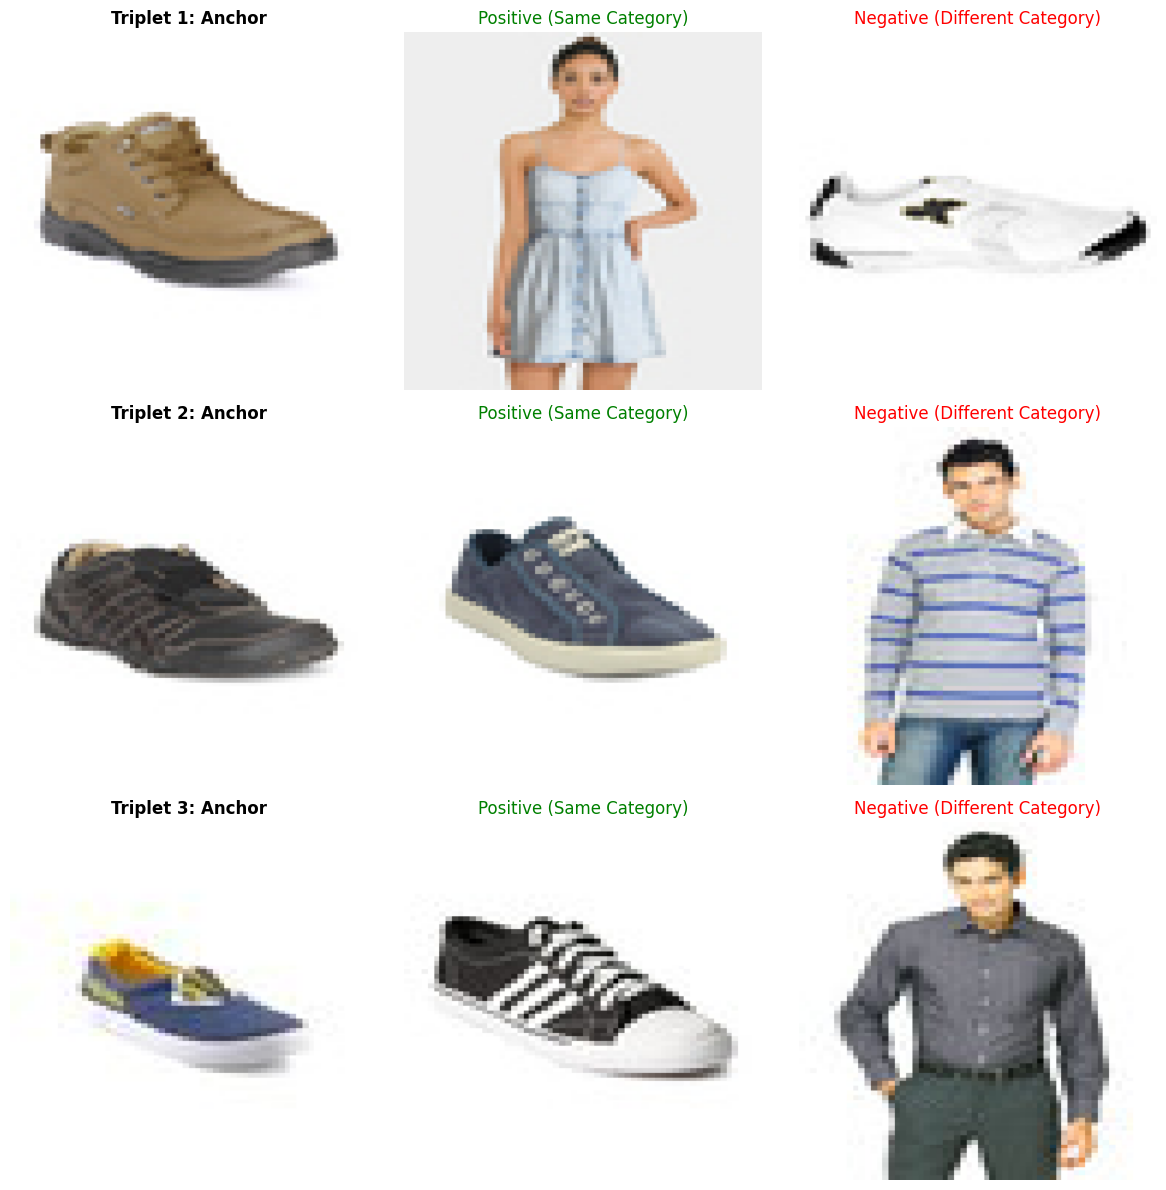

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

def plot_triplets(triplets, num_samples=3):
    # Set up the matplotlib figure size based on the number of samples
    plt.figure(figsize=(12, 4 * num_samples))

    for i in range(num_samples):
        anchor_path, positive_path, negative_path = triplets[i]

        # 1. Plot Anchor Image
        plt.subplot(num_samples, 3, i * 3 + 1)
        anchor_img = image.load_img(anchor_path, target_size=(224, 224))
        plt.imshow(anchor_img)
        plt.title(f"Triplet {i+1}: Anchor", fontweight='bold')
        plt.axis("off")

        # 2. Plot Positive Image
        plt.subplot(num_samples, 3, i * 3 + 2)
        positive_img = image.load_img(positive_path, target_size=(224, 224))
        plt.imshow(positive_img)
        plt.title("Positive (Same Category)", color='green')
        plt.axis("off")

        # 3. Plot Negative Image
        plt.subplot(num_samples, 3, i * 3 + 3)
        negative_img = image.load_img(negative_path, target_size=(224, 224))
        plt.imshow(negative_img)
        plt.title("Negative (Different Category)", color='red')
        plt.axis("off")

    plt.tight_layout()
    plt.show()

# Call the function to display the first 3 triplets in your list
plot_triplets(triplet_paths, num_samples=3)

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Input, Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model

# 1. Build the Base Feature Extractor (ResNet50)
base_cnn = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze most of the model, leaving only the very end trainable for fine-tuning
base_cnn.trainable = True
for layer in base_cnn.layers[:-15]:
    layer.trainable = False

# Add custom layers to compress the features into a 256-dimensional embedding
x = base_cnn.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation=None)(x)
# L2 Normalize the embeddings so distance calculations work correctly
x = tf.keras.layers.Lambda(lambda t: tf.math.l2_normalize(t, axis=1))(x)

embedding_model = Model(base_cnn.input, x, name="Embedding_Model")

# 2. Build the Multi-Input Siamese Network
anchor_input = Input(shape=(224, 224, 3), name='anchor')
positive_input = Input(shape=(224, 224, 3), name='positive')
negative_input = Input(shape=(224, 224, 3), name='negative')

# Pass all three inputs through the EXACT SAME embedding model (shared weights)
emb_a = embedding_model(anchor_input)
emb_p = embedding_model(positive_input)
emb_n = embedding_model(negative_input)

# The final model takes 3 images and outputs 3 numerical embeddings
siamese_network = Model(inputs=[anchor_input, positive_input, negative_input],
                        outputs=[emb_a, emb_p, emb_n],
                        name="Siamese_Network")

siamese_network.summary()

Model: "Siamese_Network"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ anchor (InputLayer) │ (None, 224, 224,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positive            │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ negative            │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Embedding_Model     │ (None, 256)       │ 24,112,256 │ anchor[0][0],     │
│ (Functional)        │                   │            │ positive[0][0],   │
│                     │                   │            │ negative[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 24,112,256 (91.98 MB)

 Trainable params: 6,044,928 (23.06 MB)

 Non-trainable params: 18,067,328 (68.92 MB)

In [ ]:
class SiameseModel(Model):
    def __init__(self, siamese_network, margin=0.5):
        super(SiameseModel, self).__init__()
        self.siamese_network = siamese_network
        self.margin = margin
        self.loss_tracker = tf.keras.metrics.Mean(name="loss")

    def call(self, inputs):
        return self.siamese_network(inputs)

    def train_step(self, data):
        # We will feed the model tuples of (anchor, positive, negative) images
        with tf.GradientTape() as tape:
            emb_a, emb_p, emb_n = self.siamese_network(data)

            # Calculate Euclidean distances between the embeddings
            ap_distance = tf.reduce_sum(tf.square(emb_a - emb_p), axis=-1)
            an_distance = tf.reduce_sum(tf.square(emb_a - emb_n), axis=-1)

            # Triplet Loss Logic: We want (Anchor->Positive distance) to be smaller
            # than (Anchor->Negative distance) by at least the margin amount.
            loss = tf.maximum(ap_distance - an_distance + self.margin, 0.0)

        # Calculate gradients and update the weights
        gradients = tape.gradient(loss, self.siamese_network.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.siamese_network.trainable_weights))

        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}

# Initialize the model and compile it with an optimizer
model = SiameseModel(siamese_network)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001))

In [ ]:
import tensorflow as tf

# 1. Separate our triplets into three parallel lists
anchor_paths = [triplet[0] for triplet in triplet_paths]
positive_paths = [triplet[1] for triplet in triplet_paths]
negative_paths = [triplet[2] for triplet in triplet_paths]

# 2. Define a function to load and preprocess a single image
def preprocess_image(file_path):
    # Read the raw file from disk
    image_string = tf.io.read_file(file_path)
    # Decode the JPEG into a tensor
    image = tf.image.decode_jpeg(image_string, channels=3)
    # Resize to the 224x224 required by ResNet50
    image = tf.image.resize(image, [224, 224])
    # Apply ResNet50 specific preprocessing (centers the pixels)
    image = tf.keras.applications.resnet50.preprocess_input(image)
    return image

# 3. Define a function to process an entire triplet at once
def process_triplet(anchor_path, positive_path, negative_path):
    return (preprocess_image(anchor_path),
            preprocess_image(positive_path),
            preprocess_image(negative_path))

# 4. Create raw datasets from our file paths
anchor_dataset = tf.data.Dataset.from_tensor_slices(anchor_paths)
positive_dataset = tf.data.Dataset.from_tensor_slices(positive_paths)
negative_dataset = tf.data.Dataset.from_tensor_slices(negative_paths)

# 5. Zip them together so they iterate in sync
dataset = tf.data.Dataset.zip((anchor_dataset, positive_dataset, negative_dataset))

# 6. Build the final pipeline
batch_size = 32
dataset = dataset.map(process_triplet, num_parallel_calls=tf.data.AUTOTUNE)
dataset = dataset.batch(batch_size, drop_remainder=True)
dataset = dataset.prefetch(tf.data.AUTOTUNE)

print("Data pipeline successfully configured.")

# 7. Start the Training Process!
# We will run this for 5 epochs as a baseline.
# Since we are using a custom training step, we don't need 'y' labels, just the dataset.
epochs = 5
print(f"Beginning training for {epochs} epochs...")
history = model.fit(dataset, epochs=epochs)

In [ ]:
import numpy as np
import faiss
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

print("Extracting new embeddings with the trained Siamese network...")
new_embeddings_list = []

# 1. Loop through our subset and extract features using the NEW model
for path in filtered_image_paths:
    # Use the preprocess function from our data pipeline
    img = preprocess_image(path)
    img_expanded = tf.expand_dims(img, axis=0)

    # Generate the 256-dimensional embedding
    embedding = embedding_model.predict(img_expanded, verbose=0)
    new_embeddings_list.append(embedding.flatten())

fine_tuned_embeddings = np.array(new_embeddings_list)

# 2. Build a new FAISS index for the fine-tuned embeddings
dimension = fine_tuned_embeddings.shape[1]
index_finetuned = faiss.IndexFlatIP(dimension)
faiss.normalize_L2(fine_tuned_embeddings)
index_finetuned.add(fine_tuned_embeddings)

# 3. Test the network with a query image (using the first image in the subset)
query_path = filtered_image_paths[0]
query_img = preprocess_image(query_path)
query_expanded = tf.expand_dims(query_img, axis=0)
query_emb = embedding_model.predict(query_expanded, verbose=0)

faiss.normalize_L2(query_emb)
k = 5
distances, indices = index_finetuned.search(query_emb, k)

# 4. Visualize the new, improved recommendations
retrieved_indices = indices[0]
plt.figure(figsize=(15, 5))

# Plot Query
plt.subplot(1, k + 1, 1)
plt.imshow(image.load_img(query_path))
plt.title("Query Image", fontweight='bold')
plt.axis('off')

# Plot Recommendations
for i, idx in enumerate(retrieved_indices):
    plt.subplot(1, k + 1, i + 2)
    recommended_path = filtered_image_paths[idx]
    plt.imshow(image.load_img(recommended_path))
    plt.title(f"Recommendation {i+1}\nScore: {distances[0][i]:.2f}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
def calculate_metrics(query_index, retrieved_indices, all_labels, k=5):
    # The ground-truth category of our query image
    query_category = all_labels[query_index]

    # The categories of the top-K recommendations
    retrieved_categories = [all_labels[idx] for idx in retrieved_indices]

    # Count how many of the top-K retrieved images match the query's category
    relevant_items_in_top_k = sum([1 for cat in retrieved_categories if cat == query_category])

    # Count total possible relevant items in the entire subset (excluding the query itself)
    total_relevant_items = sum([1 for cat in all_labels if cat == query_category]) - 1

    # Calculate Precision and Recall
    precision_at_k = relevant_items_in_top_k / k
    recall_at_k = relevant_items_in_top_k / total_relevant_items if total_relevant_items > 0 else 0

    return precision_at_k, recall_at_k

# We use index 0 because that was the query image we tested in the previous step
query_idx = 0
precision, recall = calculate_metrics(query_index=query_idx,
                                      retrieved_indices=retrieved_indices,
                                      all_labels=filtered_labels,
                                      k=5)

print(f"Quantitative Evaluation for Query Image (Top-5 Retrieval):")
print(f"Precision@5: {precision:.2f} (Meaning {precision*100}% of the recommendations were correct)")
print(f"Recall@5: {recall:.4f}")

In [ ]:
!pip install -q streamlit
!npm install localtunnel

In [ ]:
%%writefile app.py
import streamlit as st
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import faiss
from PIL import Image
import pickle

st.title("Visual Product Recommendation Engine")
st.write("Upload a clothing item to find visually similar products!")

# In a real deployment, you would load your saved model and FAISS index here
# For example:
# embedding_model = tf.keras.models.load_model('siamese_embedding_model.h5')
# index = faiss.read_index('fashion_index.faiss')

uploaded_file = st.file_uploader("Choose an image...", type=["jpg", "jpeg", "png"])

if uploaded_file is not None:
    # Display the uploaded image
    img = Image.open(uploaded_file)
    st.image(img, caption='Uploaded Image', use_column_width=True)

    st.write("Extracting features and searching for similar products...")

    # Note: To make this fully functional, you must save your trained `embedding_model`,
    # your `fine_tuned_embeddings`, and your `filtered_image_paths` to disk in your Colab
    # session, then load them into this script to perform the FAISS search dynamically.
    st.info("UI structure is ready! Connect your saved model and FAISS index to display results here.")

In [ ]:
import urllib
print("Your Local IP is:", urllib.request.urlopen('https://ipv4.icanhazip.com').read().decode('utf8').strip())

!streamlit run app.py & npx localtunnel --port 8501